In [1]:
from sklearn.calibration import calibration_curve, CalibrationDisplay, CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from kafkanator.dataviz import reliability_diagram_plot
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

In [2]:
import pandas as pd
import numpy as np

<h3> 1. Adult Dataset Download : The cell just beneath contains the code to download the ADULT dataset directly from the UCIML, sometimes
it doesnt work, in that case download the dataset here ( https://archive.ics.uci.edu/dataset/2/adult ) and plug it in the second cell beneath </h3> 

In [3]:
from ucimlrepo import fetch_ucirepo 
# fetch dataset 
adult = fetch_ucirepo(id=2) 
# data (as pandas dataframes) 
data = adult.data.features 
y = adult.data.targets 
# Data cleaning
y['income'] = y['income'].apply(lambda x: x.replace('.',''))
data['sex'] = data['sex'].str.strip()
data['race'] = data['race'].str.strip()
data['marital-status'] = data['marital-status'].str.strip()
data['native-country'] = data['native-country'].str.strip()

/tmp/ipykernel_28614/1730836504.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['income'] = y['income'].apply(lambda x: x.replace('.',''))
/tmp/ipykernel_28614/1730836504.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['sex'] = data['sex'].str.strip()
/tmp/ipykernel_28614/1730836504.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyda

In [24]:
#data = pd.read_csv ('ENTER YOUR ADULT UCIML FILE PATH HERE',names=[ 'age','workclass','fnlwgt','education','education-num','marital-status','occupation','relationship','race','sex','capital-gain','capital-loss','hours-per-week','native-country','income'] ) 
y= pd.DataFrame(data=data['income'])

In [4]:
data['race'] = data['race'].apply(lambda x : 1 if x=='White' else 0 )
categorical_columns = ['workclass', 'education',  'occupation', 'relationship', 'race', 'sex','marital-status','native-country']

# Create an instance of LabelEncoder
label_encoder = LabelEncoder()

# Encode each categorical column and create new feature columns
for col in categorical_columns:
    encoded_col_name = f"{col}_encoded"
    data[encoded_col_name] = label_encoder.fit_transform(data[col])

/tmp/ipykernel_28614/2740594744.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['race'] = data['race'].apply(lambda x : 1 if x=='White' else 0 )


In [5]:
X = data[['age','workclass_encoded', 'education_encoded','education-num','marital-status_encoded','occupation_encoded',	'relationship_encoded','race_encoded','sex_encoded','capital-loss','capital-gain','hours-per-week','native-country_encoded']]
y["income"] = label_encoder.fit_transform(y['income'])

/tmp/ipykernel_28614/840463995.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y["income"] = label_encoder.fit_transform(y['income'])


In [6]:
X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size=0.3, random_state=42)

<h3> 2. Random Forest predictor without calibration . </h3>

In [7]:
from sklearn.ensemble import RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Step 4: Make predictions on the testing set
y_pred_probs = rf_classifier.predict_proba(X_test)
forest_predictions = [x[1] for x in y_pred_probs]

/home/jsaray/env_jupyterlab/lib/python3.11/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [8]:
X_test['Prediction'] = forest_predictions
X_test['Real'] = y_test

<h3> 3. Invoke reliability_diagram_plot in your test set, by sending the sensitive column, sensistive values, prediction and reality column. </h3>

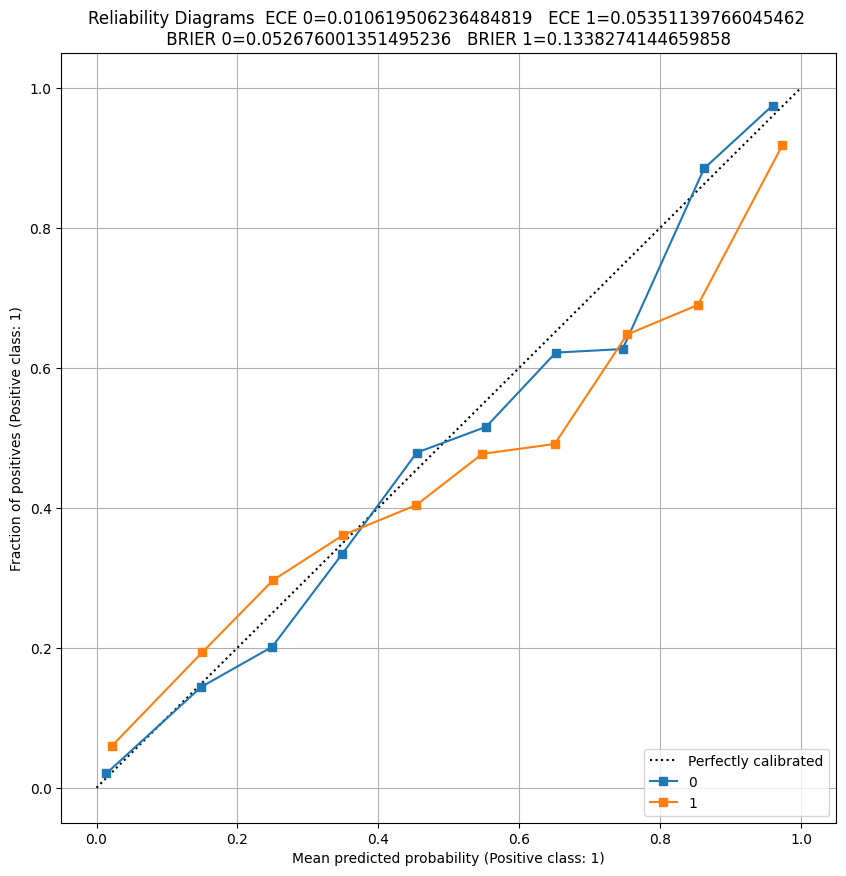

In [9]:
alldata = reliability_diagram_plot ( X_test, 'sex_encoded', [0,1], 'Prediction' , 'Real' )

<h3> Random Forest predictor with Calibration </h3>

In [11]:
X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size=0.3, random_state=42)
rf_classifier2 = RandomForestClassifier(n_estimators=100, random_state=42)
calibrated_rforest = CalibratedClassifierCV( rf_classifier2 , cv = 4, method='sigmoid' )
calibrated_rforest.fit(X_train, y_train)

/home/jsaray/env_jupyterlab/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/jsaray/env_jupyterlab/lib/python3.11/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/jsaray/env_jupyterlab/lib/python3.11/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/jsaray/env_jupyterlab/lib/python3.11/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was exp

CalibratedClassifierCV(cv=4, estimator=RandomForestClassifier(random_state=42))

In [12]:
y_log_probs_calibrated = calibrated_rforest.predict_proba(X_test)
forest_predictions_cal = [x[1] for x in y_log_probs_calibrated]

In [13]:
X_test['Prediction'] = forest_predictions_cal
X_test['Real'] = y_test

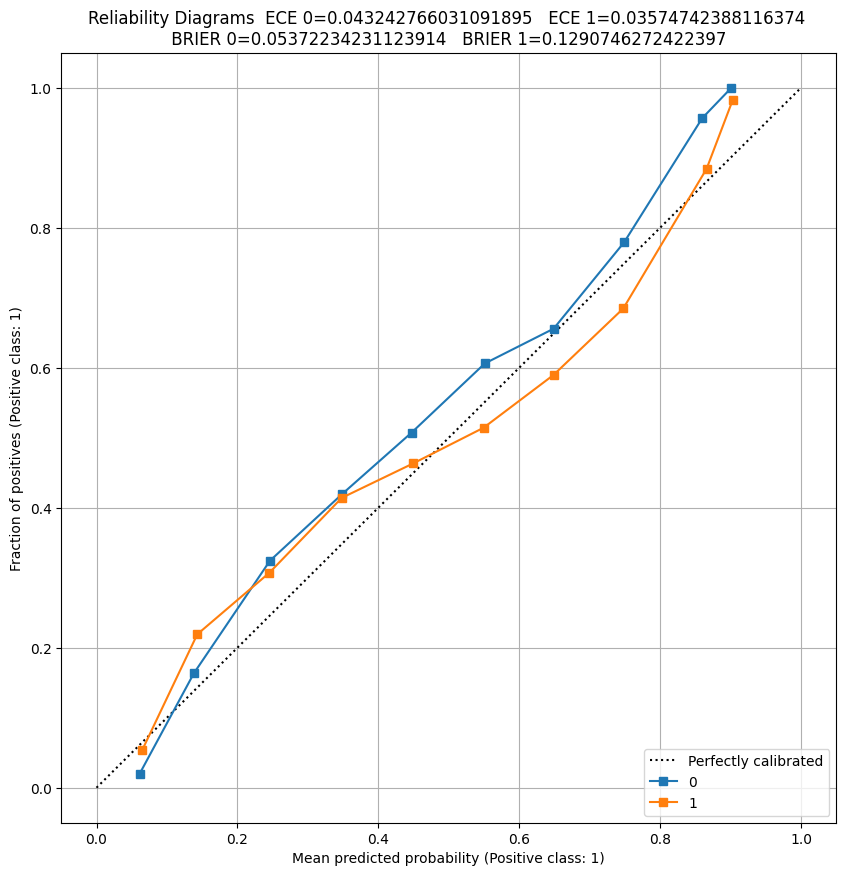

In [14]:
alldata = reliability_diagram_plot ( X_test, 'sex_encoded', [0,1], 'Prediction' , 'Real' )

<h3> Logistic Regression without calibration </h3>

/home/jsaray/env_jupyterlab/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


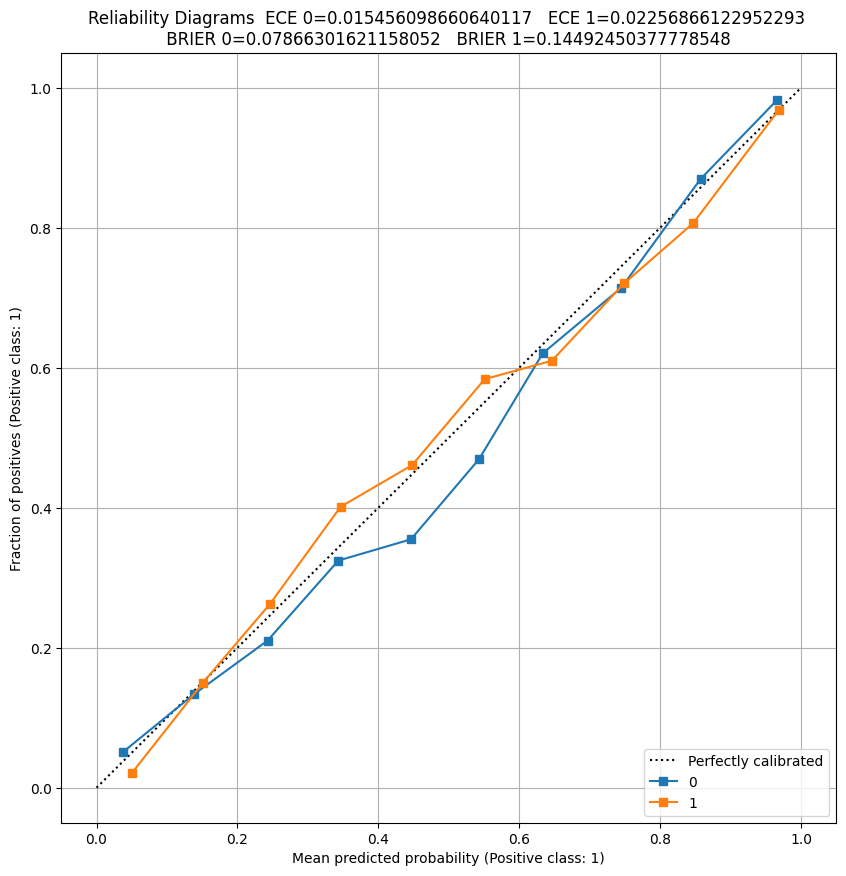

In [18]:
scaler = StandardScaler()
X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size=0.3, random_state=42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train the Logistic Regression Model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
y_log_probs = model.predict_proba(X_test_scaled)
logistic_predictions = [x[1] for x in y_log_probs]
X_test['Prediction'] = logistic_predictions
X_test['Real'] = y_test
alldata = reliability_diagram_plot ( X_test, 'sex_encoded', [0,1], 'Prediction' , 'Real' )

<h3>Logistic Regression with Calibration</h3>

In [20]:
scaler = StandardScaler()
X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size=0.3, random_state=42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train the Logistic Regression Model
logregmodel = LogisticRegression(max_iter=1000, random_state=42)
calibrated_log_reg = CalibratedClassifierCV( logregmodel , cv = 4 )
calibrated_log_reg.fit(X_train_scaled, y_train)

/home/jsaray/env_jupyterlab/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/jsaray/env_jupyterlab/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/jsaray/env_jupyterlab/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/jsaray/env_jupyterlab/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array

CalibratedClassifierCV(cv=4,
                       estimator=LogisticRegression(max_iter=1000,
                                                    random_state=42))

In [21]:
y_cal_log_probs = calibrated_log_reg.predict_proba(X_test_scaled)
logistic_calibrated_predictions = [x[1] for x in y_cal_log_probs]
X_test['Prediction'] = logistic_calibrated_predictions
X_test['Real'] = y_test

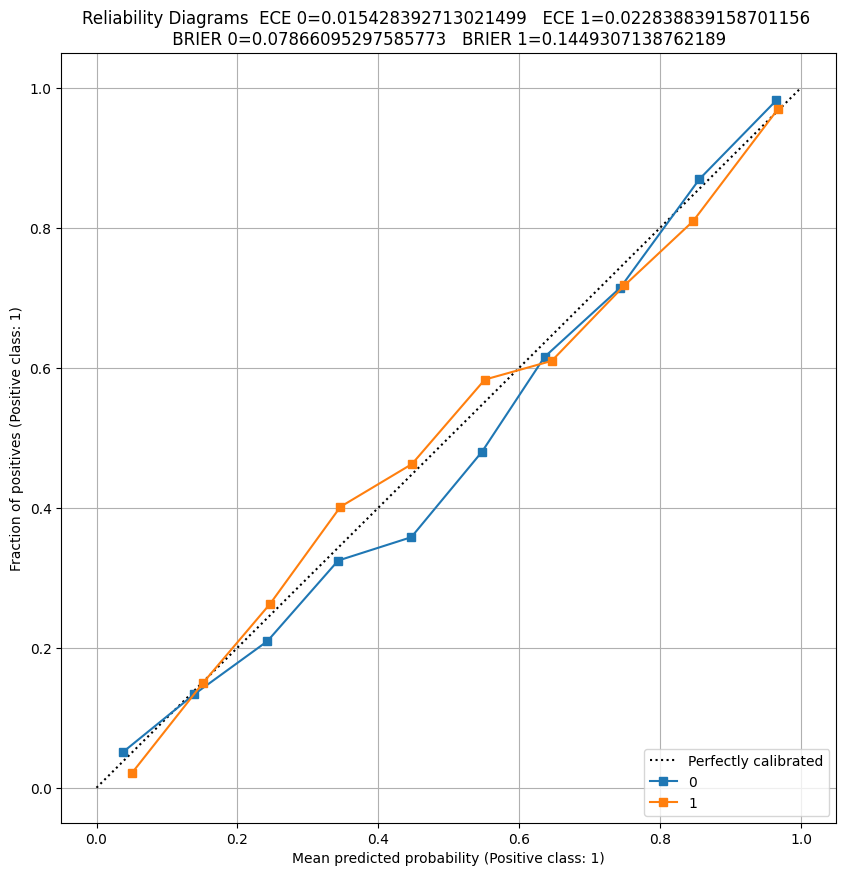

In [22]:
alldata = reliability_diagram_plot ( X_test, 'sex_encoded', [0,1], 'Prediction' , 'Real' )